In [45]:
# Cross-validation 5 razy - ale tylko na finalnym NN!
# Bez analizy oświetlenia
import cv2
import cv2.data
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms

In [46]:
# Wczytanie danych

# WSZYSTKIE DANE
authentic_faces_path = "../../../Dane/do artykułu/authentic"
authentic_faces = []

spoof_faces_path = "../../../Dane/do artykułu/spoof"
spoof_faces = []

# Wczytanie oryginalnych twarzy
files = [f for f in os.listdir(authentic_faces_path) if f.endswith(".jpg") or f.endswith(".png") or f.endswith(".webp")] # Tylko pliki JPG, PNG i WEBP
for f in files:
    image = cv2.imread(os.path.join(authentic_faces_path, f))
    authentic_faces.append(image)

# Wczytanie podstawionych twarzy
files = [f for f in os.listdir(spoof_faces_path) if f.endswith(".jpg") or f.endswith(".png") or f.endswith(".webp")] # Tylko pliki JPG, PNG i WEBP
for f in files:
    image = cv2.imread(os.path.join(spoof_faces_path, f))
    spoof_faces.append(image)
    
# TYLKO ZE SMARTFONEM
smartphone_bezel_path = "../../../Dane/do artykułu/smartphone/bezel"
smartphone_bezel = []
smartphone_nobezel_path = "../../../Dane/do artykułu/smartphone/nobezel"
smartphone_nobezel = []

smartphone_all_path = "../../../Dane/do artykułu/smartphone/all"
smartphone_all = []
smartphone_none_path = "../../../Dane/do artykułu/smartphone/none"
smartphone_none = []

# Wczytanie obrazów z twarzą na smartfonie
files = [f for f in os.listdir(smartphone_bezel_path) if f.endswith(".jpg") or f.endswith(".png") or f.endswith(".webp")] # Tylko pliki JPG, PNG i WEBP
for f in files:
    image = cv2.imread(os.path.join(smartphone_bezel_path, f))
    smartphone_bezel.append(image)
    
# Wczytanie reszty obrazów
files = [f for f in os.listdir(smartphone_nobezel_path) if f.endswith(".jpg") or f.endswith(".png") or f.endswith(".webp")] # Tylko pliki JPG, PNG i WEBP
for f in files:
    image = cv2.imread(os.path.join(smartphone_nobezel_path, f))
    smartphone_nobezel.append(image)
    
# Wczytanie wszystkich obrazów ze smartfonami
files = [f for f in os.listdir(smartphone_all_path) if f.endswith(".jpg") or f.endswith(".png") or f.endswith(".webp")] # Tylko pliki JPG, PNG i WEBP
for f in files:
    image = cv2.imread(os.path.join(smartphone_all_path, f))
    smartphone_all.append(image)
    
# Wczytanie obrazów bez smartfonów
files = [f for f in os.listdir(smartphone_none_path) if f.endswith(".jpg") or f.endswith(".png") or f.endswith(".webp")] # Tylko pliki JPG, PNG i WEBP
for f in files:
    image = cv2.imread(os.path.join(smartphone_none_path, f))
    smartphone_none.append(image)
    
print("Wczytano", len(authentic_faces), "oryginalnych twarzy")
print("Wczytano", len(spoof_faces), "podstawionych twarzy")
print("Wczytano", len(smartphone_bezel), "obrazów z twarzą na smartfonie")
print("Wczytano", len(smartphone_all), "wszystkich obrazów ze smartfonami")

Wczytano 100 oryginalnych twarzy
Wczytano 100 podstawionych twarzy
Wczytano 54 obrazów z twarzą na smartfonie
Wczytano 74 wszystkich obrazów ze smartfonami


In [47]:
## Bezel detection
# Funkcja wykrywająca obecność ramek urządzeń elektronicznych wokół twarzy na zdjęciu wejściowym.
def detect_bezel(image, face) -> (str, bool, float):
    # Przetwarzanie wstępne obrazu wejściowego
    img_downscaled = cv2.resize(image, (256, 256), interpolation=cv2.INTER_AREA)
    img_gray = cv2.cvtColor(img_downscaled, cv2.COLOR_BGR2GRAY)

    # Uzyskanie nowej pozycji twarzy po przeskalowaniu
    (x, y, w, h) = face
    scale_factor_X = 256 / image.shape[1]
    scale_factor_Y = 256 / image.shape[0]

    x = int(x * scale_factor_X)
    y = int(y * scale_factor_Y)
    w = int(w * scale_factor_X)
    h = int(h * scale_factor_Y)

    # 1. Ustalenie parametrów początkowych
    # 2. Sprawdzenie obecności ramki w "górę"
    # 3. Stopniowa zmiana parametrów do minimalnego progu
    # 4. Powtórzenie kroku dla pozostałych trzech krawędzi
    # [PARAMETRY]
    bezels_found = 0
    max_bezel_size = 30
    min_bezel_size = 8
    gray_threshold = 28

    x_start = x + w//4
    y_start = 0
    x_end = x + 3*w//4
    y_end = y
    current_bezel_size = max_bezel_size
    candidates = []

    while current_bezel_size >= min_bezel_size:
        # Wybieramy "pasek" o szerokości current_bezel_size
        bezel = img_gray[y_start:y_start + current_bezel_size, x_start:x_end]
        # Sprawdzamy, czy średnia wartość pikseli w pasku jest mniejsza niż próg
        average = np.mean(bezel)
        if average <= gray_threshold:
            candidates.append((x_start, y_start, x_end, y_start + current_bezel_size, average))

        # Przesunięcie paska
        y_start += 1

        if y_start + current_bezel_size >= y_end:
            current_bezel_size -= 1
            y_start = 0

    # Sprawdzenie, czy znaleziono ramkę
    if len(candidates) > 0:
        bezels_found += 1

    # Wyszukiwanie w "dół"
    x_start = x + w // 4
    y_start = y + h
    x_end = x + 3 * w // 4
    y_end = 256
    current_bezel_size = max_bezel_size
    candidates = []

    while current_bezel_size >= min_bezel_size:
        # Wybieramy "pasek" o szerokości current_bezel_size
        bezel = img_gray[y_start:y_start + current_bezel_size, x_start:x_end]
        # Sprawdzamy, czy średnia wartość pikseli w pasku jest mniejsza niż próg
        average = np.mean(bezel)
        if average <= gray_threshold:
            candidates.append((x_start, y_start, x_end, y_start + current_bezel_size, average))

        # Przesunięcie paska
        y_start += 1

        if y_start + current_bezel_size >= y_end:
            current_bezel_size -= 1
            y_start = y

    # Sprawdzenie, czy znaleziono ramkę
    if len(candidates) > 0:
        bezels_found += 1

    # Wyszukiwanie w "lewo"
    x_start = 0
    y_start = y + h // 4
    x_end = x
    y_end = y + 3 * h // 4
    current_bezel_size = max_bezel_size
    candidates = []

    while current_bezel_size >= min_bezel_size:
        # Wybieramy "pasek" o szerokości current_bezel_size
        bezel = img_gray[y_start:y_end, x_start:x_start + current_bezel_size]
        # Sprawdzamy, czy średnia wartość pikseli w pasku jest mniejsza niż próg
        average = np.mean(bezel)
        if average <= gray_threshold:
            candidates.append((x_start, y_start, x_start + current_bezel_size, y_end, average))

        # Przesunięcie paska
        x_start += 1

        if x_start + current_bezel_size >= x_end:
            current_bezel_size -= 1
            x_start = 0

    # Sprawdzenie, czy znaleziono ramkę
    if len(candidates) > 0:
        bezels_found += 1

    # Wyszukiwanie w "prawo"
    x_start = x + w
    y_start = y + h // 4
    x_end = 256
    y_end = y + 3 * h // 4
    current_bezel_size = max_bezel_size
    candidates = []

    while current_bezel_size >= min_bezel_size:
        # Wybieramy "pasek" o szerokości current_bezel_size
        bezel = img_gray[y_start:y_end, x_start:x_start + current_bezel_size]
        # Sprawdzamy, czy średnia wartość pikseli w pasku jest mniejsza niż próg
        average = np.mean(bezel)
        if average <= gray_threshold:
            candidates.append((x_start, y_start, x_start + current_bezel_size, y_end, average))

        # Przesunięcie paska
        x_start += 1

        if x_start + current_bezel_size >= x_end:
            current_bezel_size -= 1
            x_start = x

    # Sprawdzenie, czy znaleziono ramkę
    if len(candidates) > 0:
        bezels_found += 1

    # Sprawdzenie, czy znaleziono co najmniej 2 ramki
    if bezels_found >= 2:
        return "-BEZEL_INFO-", True, 1.0
    else:
        return "-BEZEL_INFO-", False, 0.0

In [48]:
# Testy wykrywania ramek
# Dla zdjęć, które zawierają ramkę
print("---ZDJĘCIA Z RAMKĄ---")
for image in smartphone_bezel:
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    
    if len(faces) == 0:
        continue
    
    # Największa twarz
    face = max(faces, key=lambda x: x[2] * x[3])
    
    for (x, y, w, h) in faces:
        # Wykrywanie ramki
        bezel_info, bezel_found, bezel_score = detect_bezel(image, (x, y, w, h))
        print(bezel_info, bezel_found, bezel_score)
        
# Dla zdjęć, które nie zawierają ramki
print("---ZDJĘCIA BEZ RAMKI---")
for image in smartphone_nobezel:
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.1, 5)

    if len(faces) == 0:
        continue

    # Największa twarz
    face = max(faces, key=lambda x: x[2] * x[3])

    for (x, y, w, h) in faces:
        # Wykrywanie ramki
        bezel_info, bezel_found, bezel_score = detect_bezel(image, (x, y, w, h))
        print(bezel_info, bezel_found, bezel_score)

---ZDJĘCIA Z RAMKĄ---
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- False 0.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- False 0.0
-BEZEL_INFO- False 0.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- False 0.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- True 1.0
-BEZEL_INFO- False 0.0
-BEZEL_INFO- False 0.0
-BEZEL_INFO- False 0.0
-BE

In [49]:
## Smartphone detection
# Sieć
class BezelDetectionNet(nn.Module):
    def __init__(self):
        super(BezelDetectionNet, self).__init__()
        # Conv -> ReLU -> Pool -> Conv -> ReLU -> Flatten -> Fully connected -> Fully connected
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(256 * 8 * 8, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 2)    # 2 klasy na wyjściu (original, spoof)

    # Definicja przepływu danych przez sieć
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = x.view(-1, 256 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


# Wczytanie modelu
bezelDetectionNet = BezelDetectionNet()
bezelDetectionNet.load_state_dict(torch.load("../data/bezelai_model.pth"))
bezelDetectionNet.eval()

BezelDetectionNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=2, bias=True)
)

In [50]:
# Testy wykrywania smartfona
# Dla zdjęć, które zawierają smartfon
print("---ZDJĘCIA Z SMARTFONEM---")
for image in smartphone_all:
    # Przetwarzanie wstępne obrazu wejściowego
    trf = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
    ])

    image_processed = trf(image).unsqueeze(0)

    # Przekazanie obrazu do sieci neuronowej
    with torch.no_grad():
        output = bezelDetectionNet(image_processed)
        # 'result' będzie równy 0 lub 1, gdzie 1 oznacza obecność smartfona
        result = torch.argmax(output, dim=1).item()

        # Obliczenie prawdopodobieństwa, że twarz jest podstawiona
        probabilities = torch.nn.functional.softmax(output, dim=1)

        # Zwrócenie wyniku
        print("-SMARTPHONE_INFO-", result == 1, probabilities[0][1].item())
        
# Dla zdjęć, które nie zawierają smartfonu
print("---ZDJĘCIA BEZ SMARTFONU---")
for image in smartphone_none:
    # Przetwarzanie wstępne obrazu wejściowego
    trf = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
    ])

    image_processed = trf(image).unsqueeze(0)

    # Przekazanie obrazu do sieci neuronowej
    with torch.no_grad():
        output = bezelDetectionNet(image_processed)
        # 'result' będzie równy 0 lub 1, gdzie 1 oznacza obecność smartfona
        result = torch.argmax(output, dim=1).item()

        # Obliczenie prawdopodobieństwa, że twarz jest podstawiona
        probabilities = torch.nn.functional.softmax(output, dim=1)

        # Zwrócenie wyniku
        print("-SMARTPHONE_INFO-", result == 1, probabilities[0][1].item())

---ZDJĘCIA Z SMARTFONEM---
-SMARTPHONE_INFO- True 1.0
-SMARTPHONE_INFO- True 0.9999997615814209
-SMARTPHONE_INFO- False 1.213705945701804e-05
-SMARTPHONE_INFO- True 1.0
-SMARTPHONE_INFO- True 0.9876920580863953
-SMARTPHONE_INFO- True 0.9249367117881775
-SMARTPHONE_INFO- True 1.0
-SMARTPHONE_INFO- True 1.0
-SMARTPHONE_INFO- True 1.0
-SMARTPHONE_INFO- True 1.0
-SMARTPHONE_INFO- True 1.0
-SMARTPHONE_INFO- True 0.9999998807907104
-SMARTPHONE_INFO- False 3.299229865660891e-05
-SMARTPHONE_INFO- True 0.9999923706054688
-SMARTPHONE_INFO- True 0.9999991655349731
-SMARTPHONE_INFO- True 0.9778769612312317
-SMARTPHONE_INFO- False 0.07226072996854782
-SMARTPHONE_INFO- False 3.4111712921003345e-06
-SMARTPHONE_INFO- True 1.0
-SMARTPHONE_INFO- True 0.9999995231628418
-SMARTPHONE_INFO- True 1.0
-SMARTPHONE_INFO- True 1.0
-SMARTPHONE_INFO- True 1.0
-SMARTPHONE_INFO- False 2.1106550320837414e-06
-SMARTPHONE_INFO- True 0.9972832202911377
-SMARTPHONE_INFO- True 0.9999896287918091
-SMARTPHONE_INFO- True 0.8

In [51]:
## Context analysis
data_X = np.load("../data/histogram_data_far_X.npz")
data_Y = np.load("../data/histogram_data_far_Y.npz")

# Funkcja obliczająca współrzędne i rozmiar otoczenia twarzy na zdjęciu.
def get_face_context(img, face) -> dict:
    # 1. Obliczenie proporcji twarzy w stosunku do całego obrazu
    # 2. Obliczenie współrzędnych punktów w bezpośrednim otoczeniu twarzy
    # 3. Obliczenie współrzędnych punktów w dalszym otoczeniu twarzy
    # 4. Zwrócenie współrzędnych z funkcji
    x, y, w, h = face
    img_h, img_w, _ = img.shape

    # Obliczenie proporcji twarzy w stosunku do całego obrazu
    face_proportion = (w * h) / (img_h * img_w)

    # Uznajemy, że bezpośrednie otoczenie twarzy to 40% wysokości i szerokości twarzy
    # [PARAMETR]
    context_proportion = 0.40

    # Obliczenie współrzędnych punktów w bezpośrednim otoczeniu twarzy
    rectangle_point = (x - (context_proportion * w), y - (context_proportion * h))
    rectangle_width = w + 2 * (context_proportion * w)
    rectangle_height = h + 2 * (context_proportion * h)

    # Obliczenie współrzędnych punktów w dalszym otoczeniu twarzy
    rectangle_point_far = (x - (2 * context_proportion * w), y - (2 * context_proportion * h))
    rectangle_width_far = w + 4 * (context_proportion * w)
    rectangle_height_far = h + 4 * (context_proportion * h)

    # Sprawdzenie, czy punkty nie wychodzą poza obraz
    if rectangle_point[0] < 0:
        rectangle_point = (0, rectangle_point[1])
    if rectangle_point[1] < 0:
        rectangle_point = (rectangle_point[0], 0)
    if rectangle_point[0] + rectangle_width > img_w:
        rectangle_width = img_w - rectangle_point[0]
    if rectangle_point[1] + rectangle_height > img_h:
        rectangle_height = img_h - rectangle_point[1]

    if rectangle_point_far[0] < 0:
        rectangle_point_far = (0, rectangle_point_far[1])
    if rectangle_point_far[1] < 0:
        rectangle_point_far = (rectangle_point_far[0], 0)
    if rectangle_point_far[0] + rectangle_width_far > img_w:
        rectangle_width_far = img_w - rectangle_point_far[0]
    if rectangle_point_far[1] + rectangle_height_far > img_h:
        rectangle_height_far = img_h - rectangle_point_far[1]

    # Zwrócenie wartości
    return {
        'face_proportion': face_proportion,
        'rectangle_point': rectangle_point,
        'rectangle_width': rectangle_width,
        'rectangle_height': rectangle_height,
        'rectangle_point_far': rectangle_point_far,
        'rectangle_width_far': rectangle_width_far,
        'rectangle_height_far': rectangle_height_far
    }

# Funkcja tworząca histogram na podstawie wykrytych krawędzi na obrazie.
def analyze_edge_distribution(sobel):
    edge_data = sobel.flatten()

    # Utworzenie histogramu na podstawie intensywności krawędzi, podzielonego na 16 przedziałów
    # [PARAMETR]
    hist, bins = np.histogram(edge_data, bins=16)

    return hist, bins

# Funkcja analizująca otoczenie twarzy na zdjęciu wejściowym w porównaniu do oczekiwanej dystrybucji.
def analyze_context(image, face) -> (str, bool, float):
    global data_X, data_Y

    # Obliczenie otoczenia twarzy
    context = get_face_context(image, face)

    # Wycięcie 'dalszego' obszaru twarzy
    (x, y, w, h) = face
    rectangle_point_far = (int(context['rectangle_point_far'][0]), int(context['rectangle_point_far'][1]))
    rectangle_width_far = int(context['rectangle_width_far'])
    rectangle_height_far = int(context['rectangle_height_far'])

    context_area_far = image[rectangle_point_far[1]:rectangle_point_far[1] + rectangle_height_far,
                       rectangle_point_far[0]:rectangle_point_far[0] + rectangle_width_far]

    # Przetwarzanie wstępne obrazu wejściowego
    context_area_far = cv2.resize(context_area_far, (256, 256))
    context_area_far = cv2.cvtColor(context_area_far, cv2.COLOR_BGR2GRAY)

    # Sobel X
    sobel_X = cv2.Sobel(context_area_far, cv2.CV_64F, 1, 0, ksize=3)
    sobel_X = cv2.convertScaleAbs(sobel_X)

    # Sobel Y
    sobel_Y = cv2.Sobel(context_area_far, cv2.CV_64F, 0, 1, ksize=3)
    sobel_Y = cv2.convertScaleAbs(sobel_Y)

    # Analiza krawędzi - utworzenie histogramów
    hist_X, bins_X = analyze_edge_distribution(sobel_X)
    hist_Y, bins_Y = analyze_edge_distribution(sobel_Y)

    # Porównanie z oczekiwaną dystrybucją
    # [PARAMETRY]
    max_deviation = 1.5   # Ilość odchyleń standardowych (w dowolną stronę), które są uznawane za odbiegające od normy
    num_deviations = 0  # Ilość wykrytych, odbiegających od normy wartości
    min_num_deviations = 3  # Minimalna ilość wykrytych, odbiegających od normy wartości, aby uznać obraz za niespójny

    # Dla X
    z_score_X = (hist_X - data_X['hist_mean']) / data_X['hist_std']
    num_deviations += np.sum(np.abs(z_score_X) > max_deviation)

    # Dla Y
    z_score_Y = (hist_Y - data_Y['hist_mean']) / data_Y['hist_std']
    num_deviations += np.sum(np.abs(z_score_Y) > max_deviation)

    # Zwrócenie wyniku
    probability = 1.0 if num_deviations >= min_num_deviations else 0.0
    return "-CONTEXT_INFO-", bool(num_deviations >= min_num_deviations), probability

In [52]:
# Testy analizy kontekstu

# Dla twarzy autentycznych
print("---TWARZE AUTENTYCZNE---")
for image in authentic_faces:
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    
    if len(faces) == 0:
        continue
    
    # Największa twarz
    face = max(faces, key=lambda x: x[2] * x[3])
    
    # Wykrywanie kontekstu
    context_info, context_found, context_score = analyze_context(image, face)
    print(context_info, context_found, context_score)
    
# Dla twarzy podstawionych
print("---TWARZE PODSTAWIONE---")
for image in spoof_faces:
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    
    if len(faces) == 0:
        continue
    
    # Największa twarz
    face = max(faces, key=lambda x: x[2] * x[3])
    
    # Wykrywanie kontekstu
    context_info, context_found, context_score = analyze_context(image, face)
    print(context_info, context_found, context_score)

---TWARZE AUTENTYCZNE---
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- False 0.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- False 0.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- False 0.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- False 0.0
-CONTEXT_INFO- False 0.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- False 0.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- False 0.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- False 0.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- False 0.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- True 1.0
-CONTEXT_INFO- False 0.0
-CONT

In [53]:
## NN analysis
# Sieć
class SpoofDetectionNet(nn.Module):
    def __init__(self):
        super(SpoofDetectionNet, self).__init__()
        # CONV => RELU => CONV => RELU => POOL
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding='same')
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 16, kernel_size=3, padding='same')
        self.bn2 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.dropout1 = nn.Dropout(0.25)

        # CONV => RELU => CONV => RELU => POOL
        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding='same')
        self.bn3 = nn.BatchNorm2d(32)
        self.conv4 = nn.Conv2d(32, 32, kernel_size=3, padding='same')
        self.bn4 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.dropout2 = nn.Dropout(0.25)

        # FC => RELU
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 16 * 16, 64)
        self.bn5 = nn.BatchNorm1d(64)
        self.dropout3 = nn.Dropout(0.5)

        # Warstwa wyjściowa
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        # CONV => RELU => CONV => RELU => POOL
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.dropout1(x)

        # CONV => RELU => CONV => RELU => POOL
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        x = self.dropout2(x)

        # FC => RELU
        x = self.flatten(x)
        x = F.relu(self.bn5(self.fc1(x)))
        x = self.dropout3(x)

        # Klasyfikator Softmax
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)
    
# Wczytanie modelu
spoofDetectionNet = SpoofDetectionNet()
spoofDetectionNet.load_state_dict(torch.load("../data/model_closeup.pth"))
spoofDetectionNet.eval()

SpoofDetectionNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (bn4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.25, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in

In [54]:
# Testy analizy NN
# Funkcja analizująca twarz na zdjęciu wejściowym przy pomocy sieci neuronowej.
def analyze_face(image, face) -> (str, bool, float):
    global spoofDetectionNet

    # Przetwarzanie wstępne obrazu wejściowego
    # Wydzielenie obszaru wokół twarzy
    (x, y, w, h) = face
    x = max(0, x - w // 3)
    y = max(0, y - h // 3)
    w = min(image.shape[1], w * 5 // 3)
    h = min(image.shape[0], h * 5 // 3)
    face_area = image[y:y + h, x:x + w]

    # Przetworzenie obrazu
    trf = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
    ])

    face_area_processed = trf(face_area).unsqueeze(0)

    # Przekazanie obrazu do sieci neuronowej
    with torch.no_grad():
        output = spoofDetectionNet(face_area_processed)
        # 'result' będzie równy 0 lub 1, gdzie 1 oznacza twarz podstawioną
        result = torch.argmax(output, dim=1).item()

        # Obliczenie prawdopodobieństwa, że twarz jest podstawiona
        probabilities = torch.nn.functional.softmax(output, dim=1)

        # Zwrócenie wyniku
        return "-NN_INFO-", result == 1, probabilities[0][1].item()
    
# Dla twarzy autentycznych
print("---TWARZE AUTENTYCZNE---")
for image in authentic_faces:
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    
    if len(faces) == 0:
        continue
    
    # Największa twarz
    face = max(faces, key=lambda x: x[2] * x[3])
    
    # Analiza NN
    nn_info, nn_found, nn_score = analyze_face(image, face)
    print(nn_info, nn_found, nn_score)
    
# Dla twarzy podstawionych
print("---TWARZE PODSTAWIONE---")
for image in spoof_faces:
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    
    if len(faces) == 0:
        continue
    
    # Największa twarz
    face = max(faces, key=lambda x: x[2] * x[3])
    
    # Analiza NN
    nn_info, nn_found, nn_score = analyze_face(image, face)
    print(nn_info, nn_found, nn_score)

---TWARZE AUTENTYCZNE---
-NN_INFO- False 0.0016533619491383433
-NN_INFO- False 0.0011303615756332874
-NN_INFO- False 0.0007887129904702306
-NN_INFO- False 0.22409504652023315
-NN_INFO- False 0.0008720891200937331
-NN_INFO- False 0.001894796034321189
-NN_INFO- False 0.0005891607725061476
-NN_INFO- False 0.0005378310452215374
-NN_INFO- False 0.00016588796279393137
-NN_INFO- True 0.7130070924758911
-NN_INFO- True 0.9070703983306885
-NN_INFO- False 0.039552364498376846
-NN_INFO- False 0.003806475317105651
-NN_INFO- False 0.0009302142425440252
-NN_INFO- False 0.0010461026104167104
-NN_INFO- False 0.004817251581698656
-NN_INFO- False 0.00010779310832731426
-NN_INFO- False 0.0002765739627648145
-NN_INFO- False 0.000775040767621249
-NN_INFO- False 2.0380262810704153e-07
-NN_INFO- False 0.002245889976620674
-NN_INFO- False 0.0034476714208722115
-NN_INFO- False 0.01239969301968813
-NN_INFO- False 0.001979218563064933
-NN_INFO- False 0.016048971563577652
-NN_INFO- False 0.0021460659336298704
-NN_

In [55]:
# Przygotowanie danych CSV dla sieci na podstawie wszystkich danych
import pandas as pd

data = pd.DataFrame(columns=['P1', 'P2', 'P3', 'P4', 'wynik'])

for image in authentic_faces:
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    
    if len(faces) == 0:
        continue
    
    # Największa twarz
    face = max(faces, key=lambda x: x[2] * x[3])
    
    # Bezel
    bezel_info, bezel_found, bezel_score = detect_bezel(image, face)
    
    # Smartphone
    trf = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
    ])
    
    image_processed = trf(image).unsqueeze(0)
    
    with torch.no_grad():
        output = bezelDetectionNet(image_processed)
        result = torch.argmax(output, dim=1).item()
        probabilities = torch.nn.functional.softmax(output, dim=1)

    # Context
    context_info, context_found, context_score = analyze_context(image, face)
    
    # NN
    nn_info, nn_found, nn_score = analyze_face(image, face)
    
    # Wiersz CSV: (P1, P2, P3, P4, wynik)
    datarow = [bezel_score, probabilities[0][1].item(), context_score, nn_score, 0]
    data.loc[len(data)] = datarow
    
for image in spoof_faces:
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.1, 5)

    if len(faces) == 0:
        continue

    # Największa twarz
    face = max(faces, key=lambda x: x[2] * x[3])

    # Bezel
    bezel_info, bezel_found, bezel_score = detect_bezel(image, face)

    # Smartphone
    trf = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
    ])

    image_processed = trf(image).unsqueeze(0)

    with torch.no_grad():
        output = bezelDetectionNet(image_processed)
        result = torch.argmax(output, dim=1).item()
        probabilities = torch.nn.functional.softmax(output, dim=1)

    # Context
    context_info, context_found, context_score = analyze_context(image, face)

    # NN
    nn_info, nn_found, nn_score = analyze_face(image, face)

    # Wiersz CSV: (P1, P2, P3, P4, wynik)
    datarow = [bezel_score, probabilities[0][1].item(), context_score, nn_score, 1]
    data.loc[len(data)] = datarow
    
# Zapis do pliku CSV
data.to_csv("../data/data_temp.csv", index=False)

In [56]:
# Cross-validation dla sieci neuronowej sprawdzającej wyniki cząstkowe - 5 razy
from sklearn.model_selection import KFold
import torch.optim as optim

# Dane są w DataFrame 'data'
X = data[['P1', 'P2', 'P3', 'P4']].values
y = data['wynik'].values

# Sieć
class ProbabilityNN(nn.Module):
    def __init__(self):
        super(ProbabilityNN, self).__init__()
        self.fc1 = nn.Linear(4, 10)
        self.fc2 = nn.Linear(10, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x
    
# Cross-validation
num_epochs = 100
learning_rate = 0.01

criterion = nn.BCELoss()

# K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True)
fold_results = []
accuracy_results = []
precision_results = []
recall_results = []

all_tps = []
all_tns = []
all_fps = []
all_fns = []

best_model = None

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f'Fold {fold + 1}')

    # Create dataloaders for training and testing
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Convert to torch tensors
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)  # BCELoss expects [N, 1]
    X_test_tensor = torch.FloatTensor(X_test)
    y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

    # Initialize model
    model = ProbabilityNN()

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        # Forward pass
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)

        # Backward and optimize
        loss.backward()
        optimizer.step()

    # Evaluate on the test set
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        test_loss = criterion(test_outputs, y_test_tensor).item()

        # Apply threshold of 0.5 to get binary predictions
        predicted = (test_outputs > 0.5).float()

        # Calculate accuracy
        correct = (predicted == y_test_tensor).sum().item()
        accuracy = correct / len(y_test_tensor)
        
        # TP - podstawione, TN - autentyczne, FP - fałszywie podstawione, FN - fałszywie autentyczne
        TP = ((predicted == 1) & (y_test_tensor == 1)).sum().item()
        TN = ((predicted == 0) & (y_test_tensor == 0)).sum().item()
        FP = ((predicted == 1) & (y_test_tensor == 0)).sum().item()
        FN = ((predicted == 0) & (y_test_tensor == 1)).sum().item()
        
        all_tps.append(TP)
        all_tns.append(TN)
        all_fps.append(FP)
        all_fns.append(FN)

        # Calculate precision and recall
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        
        if best_model is None:
            best_model = model
        
        if test_loss < criterion(best_model(X_test_tensor), y_test_tensor).item():
            best_model = model

    print(f'Fold {fold + 1}, Test Loss: {test_loss}, Accuracy: {accuracy * 100:.2f}%', f'Precision: {precision * 100:.2f}%', f'Recall: {recall * 100:.2f}%')
    fold_results.append(test_loss)
    accuracy_results.append(accuracy)
    precision_results.append(precision)
    recall_results.append(recall)

# Average test loss and accuracy across all folds
average_loss = np.mean(fold_results)
average_accuracy = np.mean(accuracy_results)
average_precision = np.mean(precision_results)
average_recall = np.mean(recall_results)

print(f'Average Test Loss: {average_loss}')
print(f'Average Accuracy: {average_accuracy * 100:.2f}%')
print(f'Average Precision: {average_precision * 100:.2f}%')
print(f'Average Recall: {average_recall * 100:.2f}%')

Fold 1
Fold 1, Test Loss: 0.2753218710422516, Accuracy: 86.49% Precision: 92.86% Recall: 76.47%
Fold 2
Fold 2, Test Loss: 0.2556961476802826, Accuracy: 91.89% Precision: 90.00% Recall: 94.74%
Fold 3
Fold 3, Test Loss: 0.20373931527137756, Accuracy: 91.89% Precision: 93.33% Recall: 87.50%
Fold 4
Fold 4, Test Loss: 0.2900313138961792, Accuracy: 91.89% Precision: 94.12% Recall: 88.89%
Fold 5
Fold 5, Test Loss: 0.2408369928598404, Accuracy: 89.19% Precision: 94.74% Recall: 85.71%
Average Test Loss: 0.2531251281499863
Average Accuracy: 90.27%
Average Precision: 93.01%
Average Recall: 86.66%


In [57]:
# Zapamiętanie modelu
torch.save(model.state_dict(), "../data/probability_nn.pth")

In [58]:
print("TP:", all_tps)
print("TN:", all_tns)
print("FP:", all_fps)
print("FN:", all_fns)

TP: [13, 18, 14, 16, 18]
TN: [19, 16, 20, 18, 15]
FP: [1, 2, 1, 1, 1]
FN: [4, 1, 2, 2, 3]


In [60]:
std_tp = np.std(all_tps)
std_tn = np.std(all_tns)
std_fp = np.std(all_fps)
std_fn = np.std(all_fns)

print("TP std:", std_tp)
print("TN std:", std_tn)
print("FP std:", std_fp)
print("FN std:", std_fn)

TP std: 2.039607805437114
TN std: 1.8547236990991407
FP std: 0.4000000000000001
FN std: 1.019803902718557


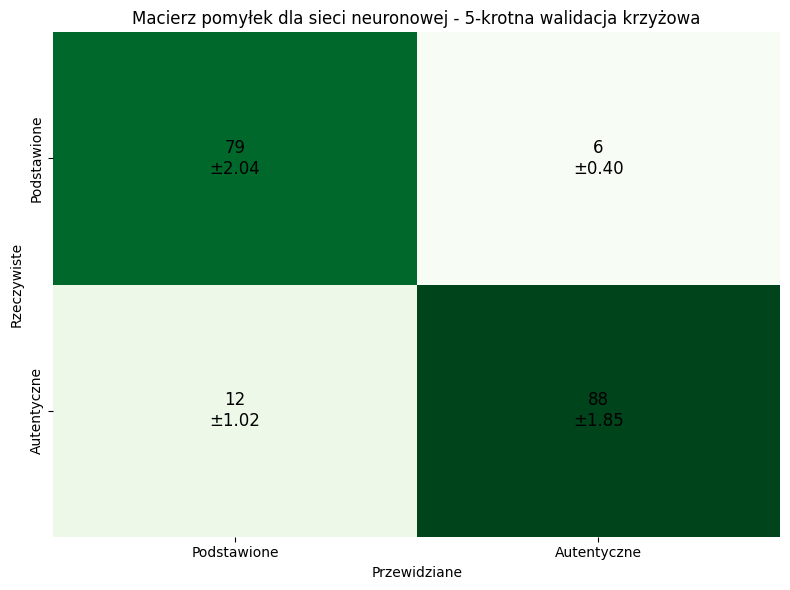

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

combined_cm = np.array([[np.sum(all_tps), np.sum(all_fps)], [np.sum(all_fns), np.sum(all_tns)]])

plt.figure(figsize=(8, 6))
ax = sns.heatmap(combined_cm, annot=False, fmt='d', cmap='Greens', cbar=False)

annotations = np.array([
    [f'{np.sum(all_tps)}\n±{std_tp:.2f}', f'{np.sum(all_fps)}\n±{std_fp:.2f}'],
    [f'{np.sum(all_fns)}\n±{std_fn:.2f}', f'{np.sum(all_tns)}\n±{std_tn:.2f}']
])

for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.5, annotations[i, j], ha='center', va='center', color="black", fontsize=12)
        

ax.set_xlabel('Przewidziane')
ax.set_ylabel('Rzeczywiste')
ax.set_xticklabels(['Podstawione', 'Autentyczne'])
ax.set_yticklabels(['Podstawione', 'Autentyczne'])
plt.title("Macierz pomyłek dla sieci neuronowej - 5-krotna walidacja krzyżowa")

plt.tight_layout()
plt.show()